In [1]:
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_PATH = Path(
    "/content/drive/MyDrive/UAH_Project"
)

embedding_path = (
    PROJECT_PATH
    / "datasets"
    / "processed"
)

sensor = np.load(
    embedding_path / "uah_dataset.npz"
)

groups = sensor["groups"]
y = sensor["y"]

video_embeddings = np.load(
    embedding_path / "video_embedding_5frames.npy"
)

print(video_embeddings.shape)

(40, 2048)


In [5]:
trip_ids = np.arange(40)

trip_labels = np.array([
    y[groups==trip][0]
    for trip in trip_ids
])

print(trip_labels)

[0 0 0 2 1 2 1 0 2 1 0 0 2 1 0 1 0 0 2 1 2 0 0 2 1 0 2 1 0 2 1 0 0 2 1 0 1
 0 1 2]


In [6]:
pca = PCA(
    n_components=2,
    random_state=42,
)

embedding_2d = pca.fit_transform(
    video_embeddings
)

print(embedding_2d.shape)

(40, 2)


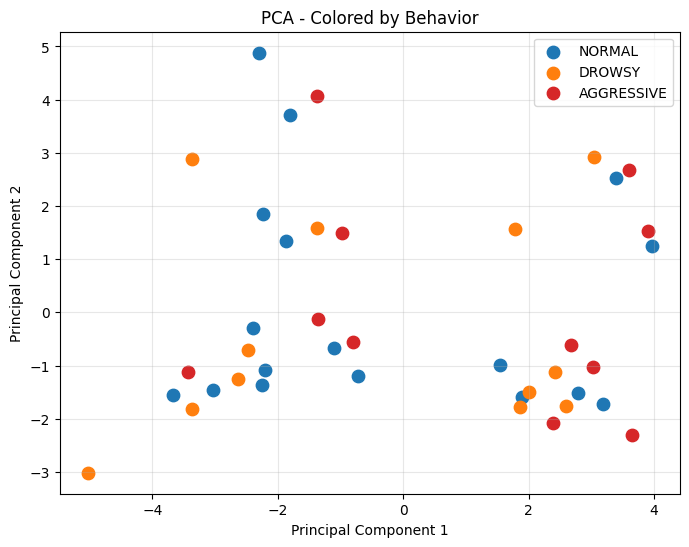

In [7]:
label_names = {
    0: "NORMAL",
    1: "DROWSY",
    2: "AGGRESSIVE",
}

colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:red",
}

plt.figure(figsize=(8,6))

for label in np.unique(trip_labels):

    idx = trip_labels == label

    plt.scatter(
        embedding_2d[idx,0],
        embedding_2d[idx,1],
        s=80,
        color=colors[label],
        label=label_names[label],
    )

plt.title("PCA - Colored by Behavior")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

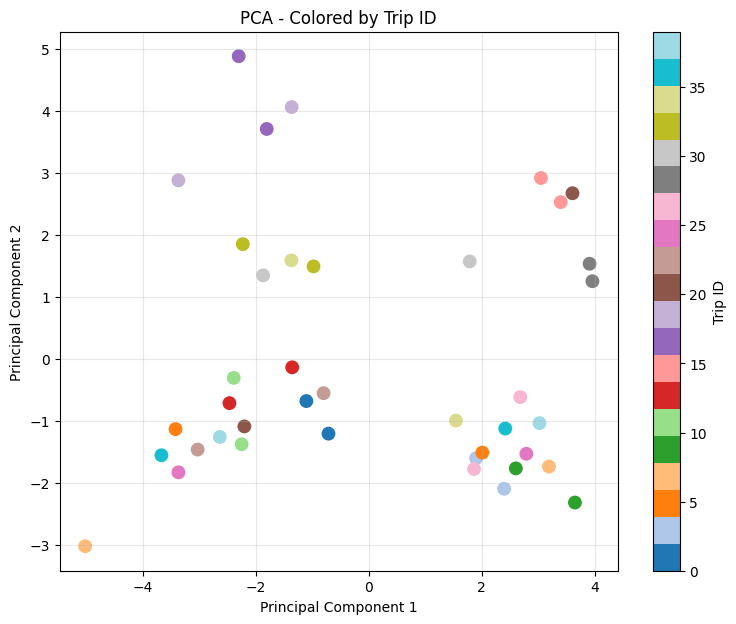

In [8]:
plt.figure(figsize=(9,7))

scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=trip_ids,
    cmap="tab20",
    s=80,
)

plt.title("PCA - Colored by Trip ID")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter,label="Trip ID")

plt.grid(alpha=0.3)

plt.show()

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

embedding_tsne = tsne.fit_transform(video_embeddings)

print(embedding_tsne.shape)

(40, 2)


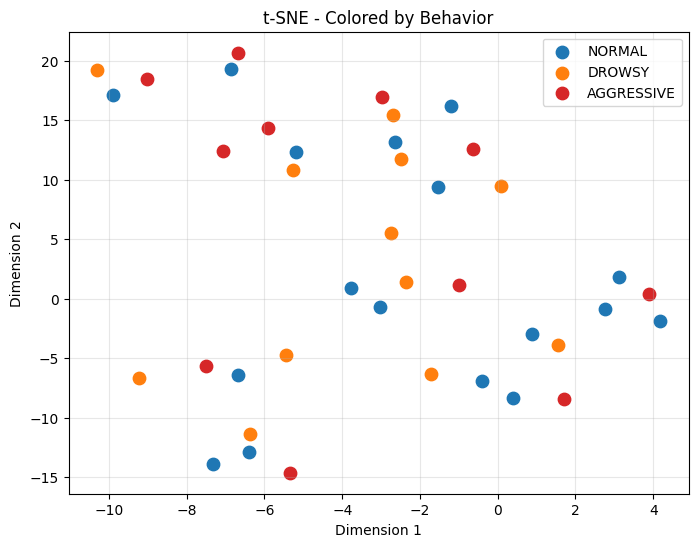

In [11]:
plt.figure(figsize=(8,6))

for label in np.unique(trip_labels):

    idx = trip_labels == label

    plt.scatter(
        embedding_tsne[idx,0],
        embedding_tsne[idx,1],
        s=80,
        color=colors[label],
        label=label_names[label],
    )

plt.title("t-SNE - Colored by Behavior")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

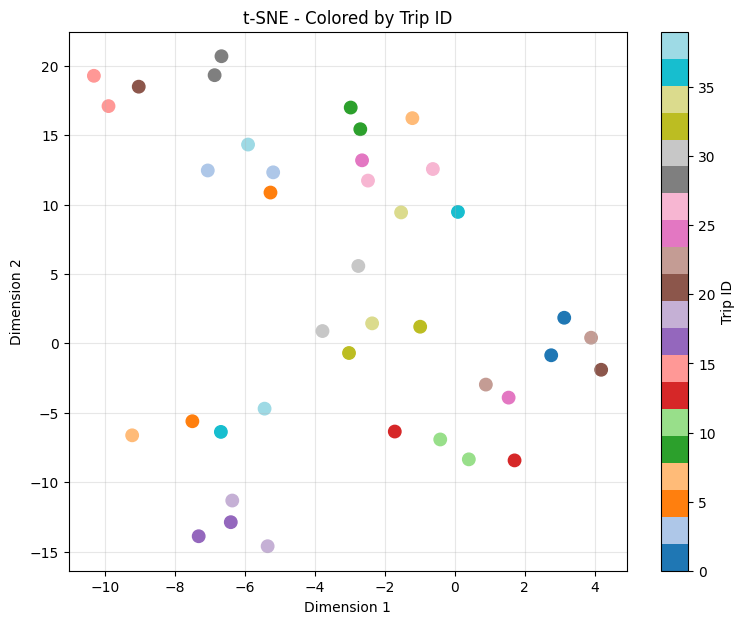

In [12]:
plt.figure(figsize=(9,7))

scatter = plt.scatter(
    embedding_tsne[:,0],
    embedding_tsne[:,1],
    c=trip_ids,
    cmap="tab20",
    s=80,
)

plt.title("t-SNE - Colored by Trip ID")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.colorbar(scatter, label="Trip ID")

plt.grid(alpha=0.3)

plt.show()

In [13]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print()

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio:
[0.26328224 0.14443253]

Total Explained Variance: 0.40771478
